# Overview

We will use a `mnist` dataset for training and testing a neural network. The first layer will have $784$ nodes, second and third layer will have $20$, and the last output layer will have $10$.

## Reference

https://medium.com/@waadlingaadil/learn-to-build-a-neural-network-from-scratch-yes-really-cac4ca457efc

# Header

In [1]:
import numpy as np # heheheha
import matplotlib.pyplot as plt # for plotting
import pandas as pd # reading csv files

# MNIST CSV Processing

In [2]:
def read_mnist_csv(filepath):
    df = pd.read_csv(filepath)
    
    y = df.iloc[:, 0].values
    Y = np.zeros((y.shape[0], 10))
    for i in range(y.shape[0]):
        Y[i, y[i]] = 1.0
    X = df.iloc[:, 1:].values
    
    X = X / 255.0
    
    return X, y

train_data = read_mnist_csv('mnist_train.csv')
test_data = read_mnist_csv('mnist_test.csv')

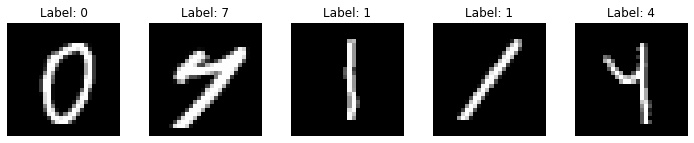

In [3]:
def mnist_visualize(data, index=0, num_images=5, figsize=(10, 2)):
    X, y = data
    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    
    for i in range(num_images):
        if num_images == 1:
            ax = axes
        else:
            ax = axes[i]
            
        img_idx = index + i
        if img_idx < len(X):
            img = X[img_idx].reshape(28, 28)
            
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Label: {y[img_idx]}")
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

mnist_visualize(train_data, index=1000, num_images=5, figsize=(10, 2))

In [4]:
def initialize_parameters():
    np.random.seed(42)

    input_size = 784  
    hidden_size1 = 20
    hidden_size2 = 20
    output_size = 10

    W1 = np.random.rand(input_size, hidden_size1) * 0.01
    b1 = np.zeros((1, hidden_size1))
    
    W2 = np.random.rand(hidden_size1, hidden_size2) * 0.01
    b2 = np.zeros((1, hidden_size2))
    
    W3 = np.random.rand(hidden_size2, output_size) * 0.01
    b3 = np.zeros((1, output_size))
    
    parameters = {"w1": W1, "b1": b1,
                  "w2": W2, "b2": b2,
                  "w3": W3, "b3": b3}
    
    return parameters

# Normalize Output

In [5]:
def normalize_output(z):
    out = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(out)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Sigma Function - PReLU

In [6]:
def PReLU(z):
    return np.where(z > 0, z, 0.001 * z)

# Neural Network

In [9]:
def forward_propagation(X, parameters):
    w1, b1 = parameters["w1"], parameters["b1"]
    w2, b2 = parameters["w2"], parameters["b2"]
    w3, b3 = parameters["w3"], parameters["b3"]

    z1 = np.dot(X, w1) + b1
    a1 = PReLU(z1)

    z2 = np.dot(a1, w2)+b2
    a2 = PReLU(z2)

    z3 = np.dot(a2, w3)+b3
    a3 = PReLU(z3)
    
    print("a3", a3)
    
    output = normalize_output(a3)
    
    print("output", output)
    cache = {"a1": a1, "a2": a2, "output": output, "z1": z1, "z2": z2, "z3": z3}
    return output, cache

forward_propagation(train_data[0][0], initialize_parameters())

a3 [[0.00571501 0.00477094 0.00559469 0.00510826 0.00560043 0.005761
  0.00528361 0.00566899 0.00499533 0.00539539]]
output [[0.10003256 0.09993817 0.10002053 0.09997189 0.1000211  0.10003717
  0.09998942 0.10002796 0.0999606  0.1000006 ]]


(array([[0.10003256, 0.09993817, 0.10002053, 0.09997189, 0.1000211 ,
         0.10003717, 0.09998942, 0.10002796, 0.0999606 , 0.1000006 ]]),
 {'a1': array([[0.50675556, 0.49507176, 0.53971291, 0.57068695, 0.52106228,
          0.50507429, 0.52104237, 0.5260207 , 0.55334628, 0.54607096,
          0.49175125, 0.53196307, 0.53693059, 0.51996252, 0.58893347,
          0.52516778, 0.51725561, 0.55677513, 0.52572958, 0.5574647 ]]),
  'a2': array([[0.03875861, 0.0552622 , 0.04699191, 0.03803181, 0.04716413,
          0.04400335, 0.05864069, 0.04811471, 0.044624  , 0.0509035 ,
          0.04810421, 0.04538919, 0.06309947, 0.05754532, 0.0576044 ,
          0.05570721, 0.05732362, 0.06462318, 0.0428065 , 0.04693843]]),
  'output': array([[0.10003256, 0.09993817, 0.10002053, 0.09997189, 0.1000211 ,
          0.10003717, 0.09998942, 0.10002796, 0.0999606 , 0.1000006 ]]),
  'z1': array([[0.50675556, 0.49507176, 0.53971291, 0.57068695, 0.52106228,
          0.50507429, 0.52104237, 0.5260207 , 0.5533

In [61]:
def forward_propagation(X, parameters):
    w1, b1 = parameters["w1"], parameters["b1"]
    w2, b2 = parameters["w2"], parameters["b2"]
    w3, b3 = parameters["w3"], parameters["b3"]

    z1 = np.dot(X, w1) + b1
    a1 = PReLU(z1)

    z2 = np.dot(a1, w2)+b2
    a2 = PReLU(z2)

    z3 = np.dot(a2, w3)+b3
    a3 = PReLU(z3)
    
    print("a3", a3)
    
    output = normalize_output(a3)
    
    print("output", output)
    print("it is:", np.argmax(output, axis=1))
    return output

forward_propagation(X[0], initialize_parameters())

a3 [[0.00651265 0.00544171 0.00638871 0.00583424 0.00639755 0.0065747
  0.00603765 0.00646357 0.00570756 0.00615845]]
output [[0.1000361  0.09992902 0.1000237  0.09996825 0.10002458 0.1000423
  0.09998859 0.10003119 0.09995559 0.10000067]]
it is: [5]


array([[0.1000361 , 0.09992902, 0.1000237 , 0.09996825, 0.10002458,
        0.1000423 , 0.09998859, 0.10003119, 0.09995559, 0.10000067]])